# Gerar datasets de treino e teste

In [8]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_PRINCIPAL = '../../dataset.csv'
PASTA_SAIDA = 'datasets'
TEST_SIZE = 0.2
RANDOM_STATE = 42

COLUNAS_ORIGINAIS = [
    'ANIMAL', 'SEXO', 'IDADE', 'PESO',
    'BICO', 'CIRCFCABECA', 'PESCOCO', 'ASA', 'TULIPA',
    'DORSO', 'VENTRE', 'CIRCFABDOM', 'SOBRECOXA',
    'COXA', 'CANELA', 'UNHAMAIOR'
]

os.makedirs(PASTA_SAIDA, exist_ok=True)

df = pd.read_csv(DATASET_PRINCIPAL, sep=';', decimal='.', encoding='utf-8')
df = df[COLUNAS_ORIGINAIS]

# Remove idades com poucos registros
contagem = df['IDADE'].value_counts()
idades_validas = contagem[contagem >= 10].index
df = df[df['IDADE'].isin(idades_validas)]

# Split por animal — os mesmos animais ficam fora do treino em todas as idades
animais = df['ANIMAL'].unique()
animais_treino, animais_teste = train_test_split(
    animais, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

treino = df[df['ANIMAL'].isin(animais_treino)]
teste  = df[df['ANIMAL'].isin(animais_teste)]

treino.to_csv(f'{PASTA_SAIDA}/dataset_treino.csv', sep=';', decimal='.', index=False, encoding='utf-8')
teste.to_csv(f'{PASTA_SAIDA}/dataset_teste.csv',   sep=';', decimal='.', index=False, encoding='utf-8')

print(f"Dataset principal: {len(df)} registros")
print(f"Animais únicos: {len(animais)} | Treino: {len(animais_treino)} | Teste: {len(animais_teste)}")
print(f"Idades: {sorted(df['IDADE'].unique().tolist())}")
print(f"\nTreino: {len(treino)} registros -> {PASTA_SAIDA}/dataset_treino.csv")
print(f"Teste:  {len(teste)} registros  -> {PASTA_SAIDA}/dataset_teste.csv")

print(f"\nRegistros por idade:")
print(f"{'Idade':>6} | {'Treino':>6} | {'Teste':>5}")
print("-"*24)
for idade in sorted(df['IDADE'].unique()):
    nt = len(treino[treino['IDADE'] == idade])
    ns = len(teste[teste['IDADE'] == idade])
    print(f"{int(idade):>6} | {nt:>6} | {ns:>5}")


Dataset principal: 2295 registros
Animais únicos: 238 | Treino: 190 | Teste: 48
Idades: [0, 7, 14, 21, 28, 38, 52, 66, 80, 101, 115]

Treino: 1836 registros -> datasets/dataset_treino.csv
Teste:  459 registros  -> datasets/dataset_teste.csv

Registros por idade:
 Idade | Treino | Teste
------------------------
     0 |    185 |    47
     7 |    186 |    46
    14 |    179 |    47
    21 |    185 |    45
    28 |    175 |    46
    38 |    179 |    46
    52 |    179 |    45
    66 |    177 |    45
    80 |    173 |    41
   101 |     96 |    20
   115 |    122 |    31


# Algoritmo Treino

In [9]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

print("="*80)
print("TREINAMENTO - PREDICAO DE PESO (XGBoost - Modelo Unificado)")
print("="*80)

FEATURES = [
    'IDADE', 'PESCOCO', 'ASA',
    'CIRCFABDOM', 'SOBRECOXA',
    'COXA', 'CANELA'
]

os.makedirs('modelos', exist_ok=True)

N_ITER = 100

param_distributions = {
    'n_estimators':     randint(50, 500),
    'max_depth':        randint(2, 6),
    'learning_rate':    uniform(0.01, 0.29),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma':            uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(0.5, 1.5)
}

# Carregar dataset de treino
dados = pd.read_csv('datasets/dataset_treino.csv', sep=';', decimal='.', encoding='utf-8')
print(f"Registros de treino: {len(dados)}")

features_disponiveis = [col for col in FEATURES if col in dados.columns]
print(f"Features: {features_disponiveis}")

for col in features_disponiveis + ['PESO']:
    dados[col] = pd.to_numeric(dados[col], errors='coerce')

dados_clean = dados.dropna(subset=features_disponiveis + ['PESO'])
n_removidas = len(dados) - len(dados_clean)
if n_removidas > 0:
    nans_por_coluna = dados[features_disponiveis + ['PESO']].isnull().sum()
    print(f"ATENCAO: {n_removidas} linhas removidas por valores faltantes")
    print(nans_por_coluna[nans_por_coluna > 0])

X = dados_clean[features_disponiveis]
y = dados_clean['PESO']

print(f"Registros para treinamento: {len(dados_clean)}")

# Treinamento com busca de hiperparametros
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTreinando ({N_ITER} iteracoes com busca aleatoria)...")

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    random_state=42,
    verbose=0
)

random_search.fit(X, y)

best_model = random_search.best_estimator_

print(f"\nMelhor R2 CV: {random_search.best_score_:.4f}")
print(f"Parametros: {random_search.best_params_}")

# Importancia das features
print(f"\nImportancia das features:")
fi = best_model.feature_importances_
for name, imp in sorted(zip(features_disponiveis, fi), key=lambda x: -x[1]):
    bar = '#' * int(imp * 50)
    print(f"  {name:<12}: {imp:.4f} {bar}")

# R2 por idade (no conjunto de treino, para referencia)
print(f"\nR2 por idade (treino):")
print(f"{'Idade':>6} | {'N':>5} | {'R2':>8}")
print("-"*26)
y_pred_treino = best_model.predict(X)
for idade in sorted(dados_clean['IDADE'].unique()):
    mask = dados_clean['IDADE'] == idade
    if mask.sum() < 10:
        continue
    r2 = r2_score(y[mask], y_pred_treino[mask])
    print(f"{int(idade):>6} | {mask.sum():>5} | {r2:>8.4f}")

# Salvar modelo
best_model.save_model('modelos/modelo_peso.json')

meta = {
    'features': features_disponiveis,
    'params': {k: (int(v) if isinstance(v, np.integer) else float(v) if isinstance(v, np.floating) else v)
               for k, v in random_search.best_params_.items()},
    'cv_score': float(random_search.best_score_)
}
with open('modelos/meta_peso.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print(f"\nModelo salvo em: modelos/modelo_peso.json")
print(f"Metadados salvos em: modelos/meta_peso.json")

print(f"\n{'='*80}")
print("TREINAMENTO CONCLUIDO!")
print(f"R2 CV geral: {random_search.best_score_:.4f}")
print(f"{'='*80}")


TREINAMENTO - PREDICAO DE PESO (XGBoost - Modelo Unificado)
Registros de treino: 1836
Features: ['IDADE', 'PESCOCO', 'ASA', 'CIRCFABDOM', 'SOBRECOXA', 'COXA', 'CANELA']
ATENCAO: 7 linhas removidas por valores faltantes
PESCOCO      1
SOBRECOXA    1
PESO         5
dtype: int64
Registros para treinamento: 1829

Treinando (100 iteracoes com busca aleatoria)...

Melhor R2 CV: 0.9409
Parametros: {'colsample_bytree': np.float64(0.9661017366676425), 'gamma': np.float64(0.28761072222235384), 'learning_rate': np.float64(0.02678053034973514), 'max_depth': 3, 'min_child_weight': 8, 'n_estimators': 205, 'reg_alpha': np.float64(0.1678300323984816), 'reg_lambda': np.float64(0.7545198558433484), 'subsample': np.float64(0.8587393446674896)}

Importancia das features:
  CIRCFABDOM  : 0.6399 ###############################
  IDADE       : 0.2478 ############
  SOBRECOXA   : 0.0656 ###
  ASA         : 0.0196 
  COXA        : 0.0115 
  PESCOCO     : 0.0085 
  CANELA      : 0.0072 

R2 por idade (treino):


# Algoritmo Teste

TESTE - PREDICAO DE PESO (XGBoost - Modelo Unificado)
Modelo carregado: R2 CV = 0.9409
Features: ['IDADE', 'PESCOCO', 'ASA', 'CIRCFABDOM', 'SOBRECOXA', 'COXA', 'CANELA']
Registros no dataset de teste: 459
ATENCAO: 2 registros removidos por valores faltantes

Metricas gerais no conjunto de teste:
  R2:   0.9296
  RMSE: 124.18g
  MAE:  74.06g

 Idade |     N |       R2 |     RMSE |      MAE |  Erro%
-------------------------------------------------------
     0 |    45 | -19.6254 |  25.79g |  14.58g |  46.4%
     7 |    46 |   0.1744 |  11.40g |   8.87g |  10.6%
    14 |    47 |  -0.2420 |  26.36g |  19.86g |  11.8%
    21 |    45 |  -0.4971 |  94.57g |  68.20g |  26.9%
    28 |    46 |  -0.0652 |  93.42g |  72.86g |  17.8%
    38 |    46 |   0.3786 | 133.31g |  87.28g |  15.8%
    52 |    45 |   0.5225 | 154.94g |  82.27g |  10.4%
    66 |    45 |   0.4839 | 131.18g | 104.62g |  10.9%
    80 |    41 |   0.1631 | 151.00g | 112.66g |   9.7%
   101 |    20 |  -0.3791 | 209.46g | 157.51g | 

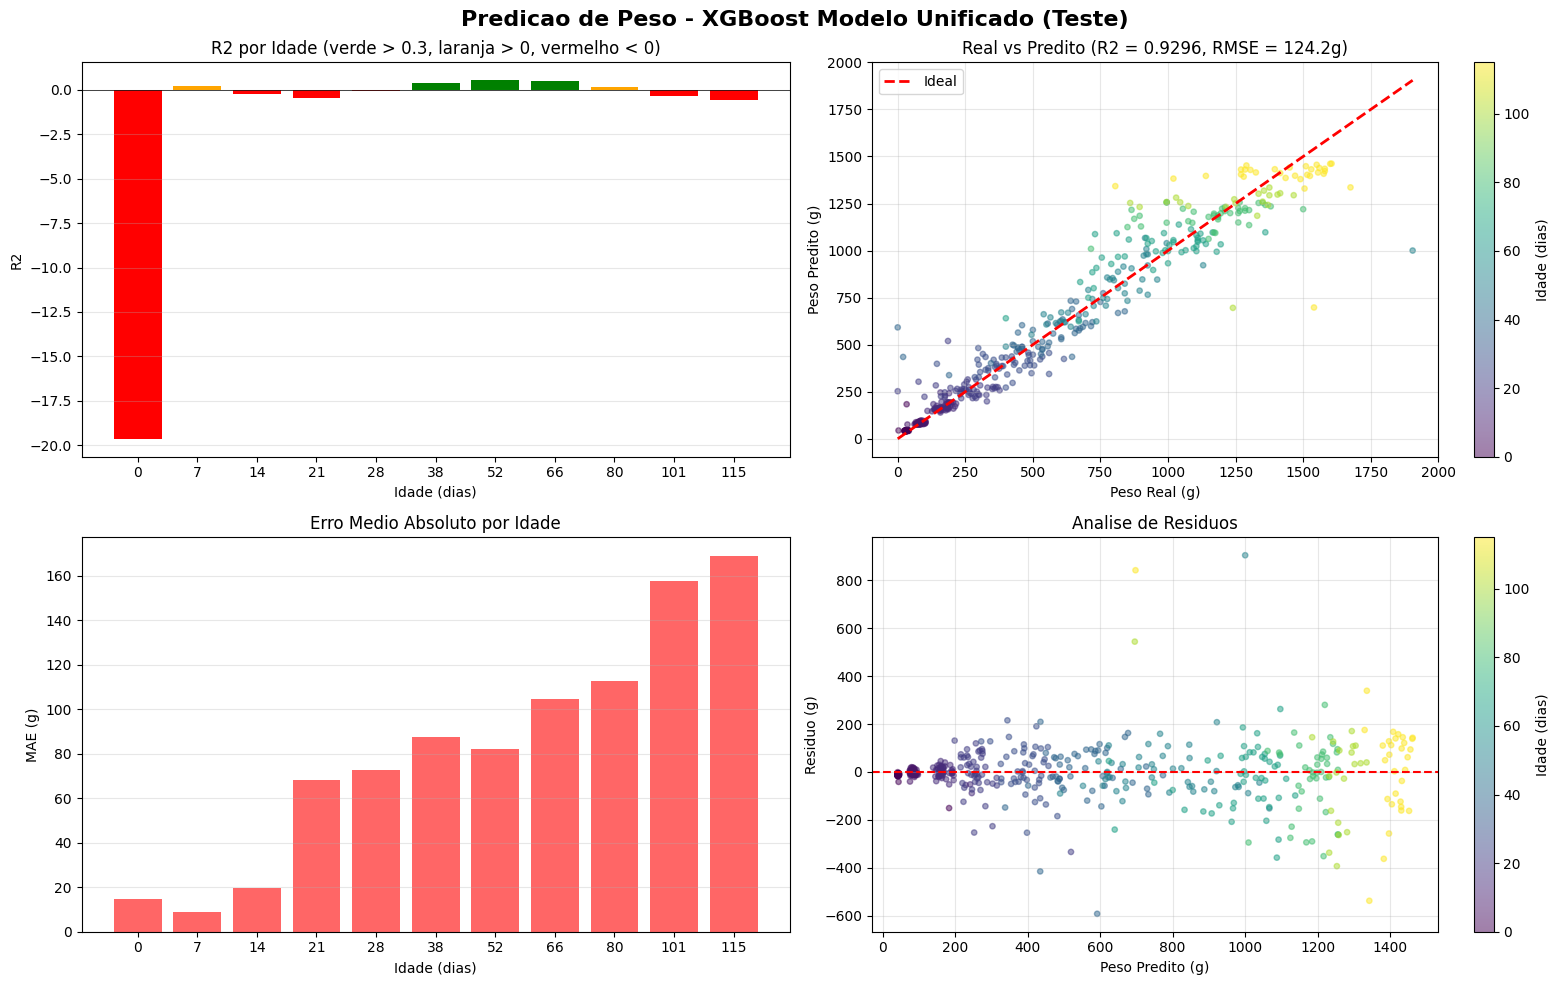


Grafico geral salvo em: resultado_xgb_teste_geral.png


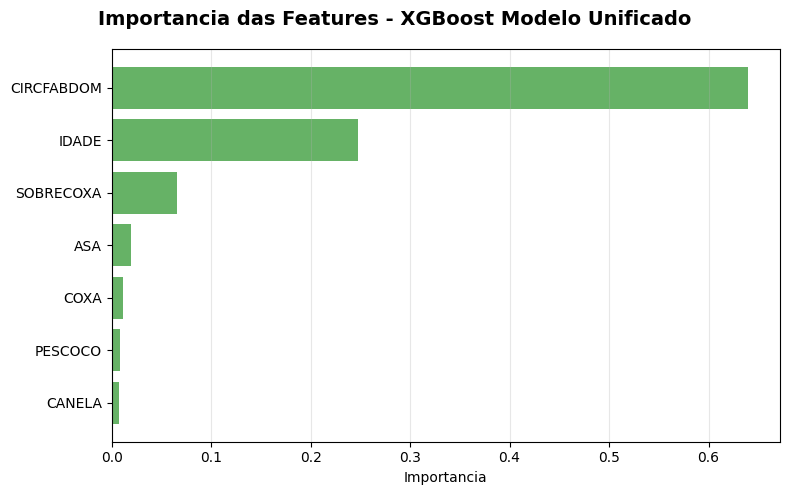

Grafico de features salvo em: resultado_xgb_teste_features.png

TESTE CONCLUIDO!
R2 geral: 0.9296 | MAE geral: 74.06g


In [10]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = [16, 10]

print("="*80)
print("TESTE - PREDICAO DE PESO (XGBoost - Modelo Unificado)")
print("="*80)

os.makedirs('predicoes', exist_ok=True)

# Carregar modelo e metadados
with open('modelos/meta_peso.json', encoding='utf-8') as f:
    meta = json.load(f)

features = meta['features']
cv_score = meta['cv_score']

model = XGBRegressor()
model.load_model('modelos/modelo_peso.json')

print(f"Modelo carregado: R2 CV = {cv_score:.4f}")
print(f"Features: {features}")

# Carregar dataset de teste
dados = pd.read_csv('datasets/dataset_teste.csv', sep=';', decimal='.', encoding='utf-8')
print(f"Registros no dataset de teste: {len(dados)}")

for col in features + ['PESO']:
    dados[col] = pd.to_numeric(dados[col], errors='coerce')

dados_pred = dados.dropna(subset=features + ['PESO']).copy()
n_removidas = len(dados) - len(dados_pred)
if n_removidas > 0:
    print(f"ATENCAO: {n_removidas} registros removidos por valores faltantes")

X = dados_pred[features]
y_real = dados_pred['PESO'].values
y_pred = model.predict(X)

# Metricas gerais
r2_geral = r2_score(y_real, y_pred)
rmse_geral = np.sqrt(mean_squared_error(y_real, y_pred))
mae_geral = mean_absolute_error(y_real, y_pred)

print(f"\nMetricas gerais no conjunto de teste:")
print(f"  R2:   {r2_geral:.4f}")
print(f"  RMSE: {rmse_geral:.2f}g")
print(f"  MAE:  {mae_geral:.2f}g")

# Metricas por idade
resumo = []
dados_plot = []

print(f"\n{'Idade':>6} | {'N':>5} | {'R2':>8} | {'RMSE':>8} | {'MAE':>8} | {'Erro%':>6}")
print("-"*55)

for idade in sorted(dados_pred['IDADE'].unique()):
    mask = dados_pred['IDADE'] == idade
    n = mask.sum()
    if n < 5:
        continue

    y_r = y_real[mask]
    y_p = y_pred[mask]

    r2 = r2_score(y_r, y_p)
    rmse = np.sqrt(mean_squared_error(y_r, y_p))
    mae = mean_absolute_error(y_r, y_p)
    erro_pct = mae / y_r.mean() * 100

    print(f"{int(idade):>6} | {n:>5} | {r2:>8.4f} | {rmse:>6.2f}g | {mae:>6.2f}g | {erro_pct:>5.1f}%")

    resumo.append({'idade': int(idade), 'n_animais': n, 'r2': r2, 'rmse': rmse, 'mae': mae})
    dados_plot.append({'idade': int(idade), 'y_real': y_r, 'y_pred': y_p})

# Salvar CSV com predicoes
resultado = pd.DataFrame({
    'ANIMAL': dados_pred['ANIMAL'].values,
    'IDADE': dados_pred['IDADE'].values.astype(int),
    'PESO_REAL': y_real,
    'PESO_PREDITO': np.round(y_pred, 2)
})
resultado.to_csv('predicoes/predicoes_teste.csv', sep=';', index=False, encoding='utf-8')
print(f"\nCSV salvo: predicoes/predicoes_teste.csv")

# === GRAFICOS ===
if dados_plot and resumo:
    all_y_real = np.concatenate([d['y_real'] for d in dados_plot])
    all_y_pred = np.concatenate([d['y_pred'] for d in dados_plot])
    all_idades = np.concatenate([np.full(len(d['y_real']), d['idade']) for d in dados_plot])
    all_residuos = all_y_real - all_y_pred

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('Predicao de Peso - XGBoost Modelo Unificado (Teste)', fontsize=16, fontweight='bold')

    # 1. R2 por idade
    plt.subplot(2, 2, 1)
    idades_r2 = [r['idade'] for r in resumo]
    scores_r2 = [r['r2'] for r in resumo]
    cores = ['green' if s > 0.3 else 'orange' if s > 0 else 'red' for s in scores_r2]
    plt.bar(range(len(idades_r2)), scores_r2, color=cores, tick_label=[str(i) for i in idades_r2])
    plt.xlabel('Idade (dias)')
    plt.ylabel('R2')
    plt.title('R2 por Idade (verde > 0.3, laranja > 0, vermelho < 0)')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='y')

    # 2. Real vs Predito
    plt.subplot(2, 2, 2)
    scatter = plt.scatter(all_y_real, all_y_pred, alpha=0.5, c=all_idades, cmap='viridis', s=15)
    plt.colorbar(scatter, label='Idade (dias)')
    min_val = min(all_y_real.min(), all_y_pred.min())
    max_val = max(all_y_real.max(), all_y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')
    plt.xlabel('Peso Real (g)')
    plt.ylabel('Peso Predito (g)')
    plt.title(f'Real vs Predito (R2 = {r2_geral:.4f}, RMSE = {rmse_geral:.1f}g)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. MAE por idade
    plt.subplot(2, 2, 3)
    idades_mae = [r['idade'] for r in resumo]
    scores_mae = [r['mae'] for r in resumo]
    plt.bar(range(len(idades_mae)), scores_mae, color='red', alpha=0.6, tick_label=[str(i) for i in idades_mae])
    plt.xlabel('Idade (dias)')
    plt.ylabel('MAE (g)')
    plt.title('Erro Medio Absoluto por Idade')
    plt.grid(True, alpha=0.3, axis='y')

    # 4. Residuos
    plt.subplot(2, 2, 4)
    scatter2 = plt.scatter(all_y_pred, all_residuos, alpha=0.5, c=all_idades, cmap='viridis', s=15)
    plt.colorbar(scatter2, label='Idade (dias)')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Peso Predito (g)')
    plt.ylabel('Residuo (g)')
    plt.title('Analise de Residuos')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('resultado_xgb_teste_geral.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGrafico geral salvo em: resultado_xgb_teste_geral.png")

    # Grafico de importancia das features (modelo unico)
    fig2, ax = plt.subplots(figsize=(8, 5))
    fig2.suptitle('Importancia das Features - XGBoost Modelo Unificado', fontsize=14, fontweight='bold')

    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)

    ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='green', alpha=0.6)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([features[i] for i in sorted_idx])
    ax.set_xlabel('Importancia')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('resultado_xgb_teste_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grafico de features salvo em: resultado_xgb_teste_features.png")

print(f"\n{'='*80}")
print("TESTE CONCLUIDO!")
print(f"R2 geral: {r2_geral:.4f} | MAE geral: {mae_geral:.2f}g")
print(f"{'='*80}")
